<h1 style="text-align: center;font-weight:bold;">Cross-Exchange Quotation</h1>


The purpose of this notebook is to analyse the behaviour of the exchanges relative to one another and the estimated index price. We want to take a closer look at how the exchanges change the premium they charge compared to the index price to be compensated for the risk they are taking in different situations.

### Import Libraries

In [11]:
import statistics
from matplotlib import pyplot as plt
import requests
import json
from concurrent.futures import ThreadPoolExecutor
import time


### Data Gathering

For simplicity, we use the estimated index price calculated by the Binance exchange, and use the mid price of each exchange.

*\* In reality, it is more accurate to estimate and calculate the weighted index price manually since the Binance approach is heavily delayed, leading to a loss of information. Additionally, the mid price does not take into account the actual fill price. Hence, using an impact price calculation provides a more accurate price estimation.*

In [12]:
# We choose BTCUSDT as the trading pair for analysis across different exchanges.

pair_list = {"binance": {"f":"BTCUSDT", "s":"BTCUSDT"},
            "kucoin": {"f":"XBTUSDTM", "s":"BTC-USDT"},
            "okx": {"f":"BTC-USD-SWAP", "s":"BTC-USDT"},
            "bitget": {"f":"BTCUSDT", "s":"BTCUSDT"},
            "bybit": {"f":"BTCUSDT", "s":"BTCUSDT"},
            "gate": {"f":"BTC_USDT", "s":"BTC_USDT"}
            }

In [13]:
# It is important to note that using multi-threading and async requests is crucial if this code is to be used for real time, live data analysis.

futures_data_list = {"binance": {"url":f"https://fapi.binance.com/fapi/v1/depth?symbol={pair_list['binance']['f']}&limit=10", "response":""},
            "kucoin": {"url":f"https://api-futures.kucoin.com/api/v1/level2/depth20?symbol={pair_list['kucoin']['f']}", "response":""},
            "okx":{"url":f"https://www.okx.com/api/v5/market/books?instId={pair_list['okx']['f']}&sz=10", "response":""},
            "bitget":{"url":f"https://api.bitget.com/api/v2/mix/market/merge-depth?productType=usdt-futures&symbol={pair_list['bitget']['f']}&precision=scale0", "response":""},
            "bybit":{"url":f"https://api.bybit.com/v5/market/orderbook?category=linear&symbol={pair_list['bybit']['f']}", "response":""},
            "gate":{"url":f"https://api.gateio.ws/api/v4/futures/usdt/order_book?contract={pair_list['gate']['f']}&limit=10", "response":""}

            }

In [14]:
# Retrieve the latest data from each exchange using multi-threading

def get_data(exchange):
    global futures_data_list

    futures_data_list[exchange]["response"]=requests.get(futures_data_list[exchange]["url"]).json()

def update_data_list():
    global futures_data_list
    exchange_list = list(futures_data_list.keys())

    with ThreadPoolExecutor() as executor:
        executor.map(get_data, exchange_list)


In [15]:
# Retrieve the index price of BTCUSDT from Binance to calculate the premium for each exchange.
def get_index_price():
    index_price = requests.get('https://fapi.binance.com/fapi/v1/premiumIndex?symbol=BTCUSDT').json()['indexPrice']
    return float(index_price)

In [16]:
# Extract the best bid and ask prices from each exchange and calculate the premium based on the index price using the average of the best bid and ask prices.
def extract_quotation_info(index_price):
    global quotation_dict
    premium_batch = []
    #Binance
    binance_best_ask_price = float(futures_data_list["binance"]["response"]["asks"][0][0])
    binance_best_bid_price = float(futures_data_list["binance"]["response"]["bids"][0][0])
    premium_batch.append((binance_best_ask_price + binance_best_bid_price) / 2 - index_price)
    # quotation_dict["binance"]["time"] = int(futures_data_list["binance"]["response"]["T"])

    #Kucoin
    kucoin_best_ask_price = float(futures_data_list["kucoin"]["response"]["data"]["asks"][0][0])
    kucoin_best_bid_price = float(futures_data_list["kucoin"]["response"]["data"]["bids"][0][0])
    premium_batch.append((kucoin_best_ask_price + kucoin_best_bid_price) / 2 - index_price)
    # quotation_dict["kucoin"]["time"] = int(futures_data_list["kucoin"]["response"]["data"]["ts"])

    #OKX
    okx_best_ask_price = float(futures_data_list["okx"]["response"]["data"][0]["asks"][0][0])
    okx_best_bid_price = float(futures_data_list["okx"]["response"]["data"][0]["bids"][0][0])
    premium_batch.append((okx_best_ask_price + okx_best_bid_price) / 2 - index_price)
    # quotation_dict["okx"]["time"] =int(futures_data_list["okx"]["response"]["data"][0]["ts"])

    #bitget
    bitget_best_ask_price = float(futures_data_list["bitget"]["response"]["data"]["asks"][0][0])
    bitget_best_bid_price = float(futures_data_list["bitget"]["response"]["data"]["bids"][0][0])
    premium_batch.append((bitget_best_ask_price + bitget_best_bid_price) / 2 - index_price)
    # quotation_dict["bitget"]["time"] = int(futures_data_list["bitget"]["response"]["data"]["ts"])

    #Bybit
    bybit_best_ask_price = float(futures_data_list["bybit"]["response"]["result"]["a"][0][0])
    bybit_best_bid_price = float(futures_data_list["bybit"]["response"]["result"]["b"][0][0])
    premium_batch.append((bybit_best_ask_price + bybit_best_bid_price) / 2 - index_price)
    # quotation_dict["bybit"]["time"] = int(futures_data_list["bybit"]["response"]["result"]["ts"])

    #Gate
    gate_best_ask_price = float(futures_data_list["gate"]["response"]["asks"][0]['p'])
    gate_best_bid_price = float(futures_data_list["gate"]["response"]["bids"][0]['p'])
    premium_batch.append((gate_best_ask_price + gate_best_bid_price) / 2 - index_price)
    # quotation_dict["gate"]["time"] = int(futures_data_list["gate"]["response"]["update"])
    
    return premium_batch

In [17]:
# Store the premiums of each exchange for the given pair (BTCUSDT in this case) for the given time period (60 seconds in this case).
premium_history = []
timer = 60 # in seconds
interval = 1 # in seconds
starting_time = time.time()
last_update_time = time.time()

while time.time() - starting_time <= timer:
    if time.time() - last_update_time >= interval:
        index_price = get_index_price()
        update_data_list()
        premium_batch = extract_quotation_info(index_price)
        premium_history.append(premium_batch)
        print(f"Batch number {len(premium_history)} was received successfully")
        last_update_time = time.time()
print("Data collection completed.")

Batch number 1 was received successfully
Batch number 2 was received successfully
Batch number 3 was received successfully
Batch number 4 was received successfully
Batch number 5 was received successfully
Batch number 6 was received successfully
Batch number 7 was received successfully
Batch number 8 was received successfully
Batch number 9 was received successfully
Batch number 10 was received successfully
Batch number 11 was received successfully
Batch number 12 was received successfully
Batch number 13 was received successfully
Batch number 14 was received successfully
Batch number 15 was received successfully
Batch number 16 was received successfully
Batch number 17 was received successfully
Data collection completed.


### The Analysis

The goal of this analysis is to observe how the market makers in each exchange adjust their premium under different conditions. We will evaluate the behaviour using three approaches: the premium history, the change in distribution skewness, and the slope of the rate of change.

#### Approach 1 (The premium)

In this approach, we track the premium of each exchange over a certain period of time, from $t_0$ to $t_1$, and then we compare the results.

In case of possible adverse selection, the market makers adjust their premiums accordingly. However, it is worth noting that using this approach, we are looking for the overall intention, and not the immediate short-span movements.

*\* In order to have more accurate results, this system can be run when major news is made public.*

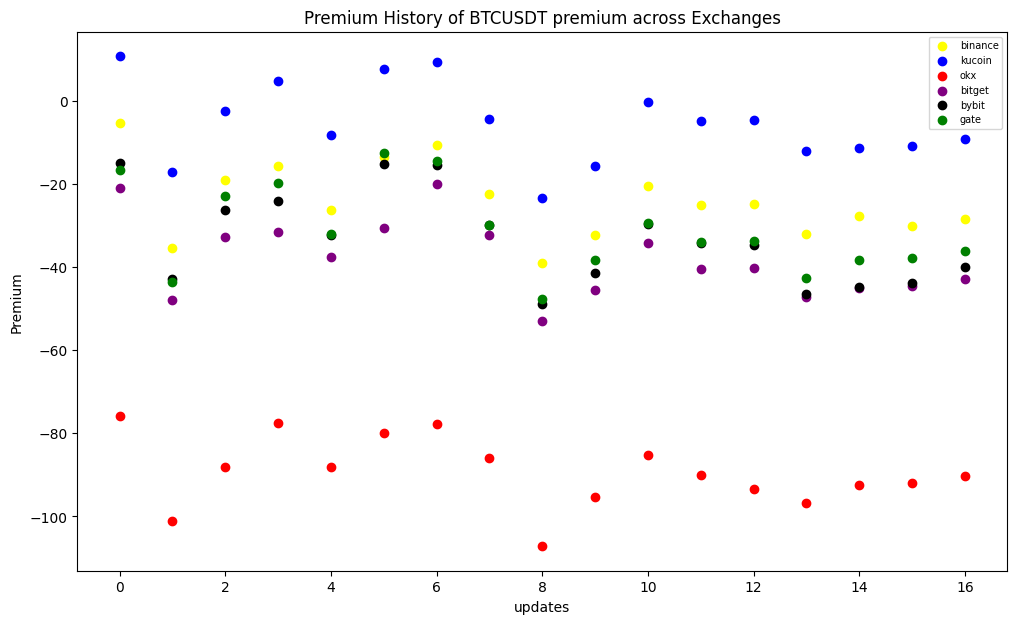

In [18]:
# plot the premium history for each exchange

exchange_names = ["binance", "kucoin", "okx", "bitget", "bybit", "gate"]
exchange_colors = ["yellow", "blue", "red", "purple", "black", "green"]

exchange_list = [[] for _ in range(len(exchange_names))]

padding = 0

plt.figure(figsize=(12, 7))
for batch in premium_history:
    for premium in range(len(batch)):
        plt.scatter(padding, batch[premium], color=exchange_colors[premium])
    

    padding +=1


plt.title("Premium History of BTCUSDT premium across Exchanges")
plt.xlabel("updates")
plt.ylabel("Premium")
plt.legend(loc='upper right', labels=exchange_names, markerscale=1, fontsize=7)
plt.show()


#### Approach 2 (Skeweness)

Using this approach, we compare the median of the premiums with the mean of the premiums. The goal is to see whether the skewness of the distribution changes from $t_0$ to $t_1$. The skewness helps us observe if the distribution of the prices is skewed upwards or downwards. Upward skewness means the exchanges are more willing to charge a higher premium compared to the medain, and downward skewness means the otherwise. As a result, a change in the skewness helps us understand the changes in the premium distribution over time.

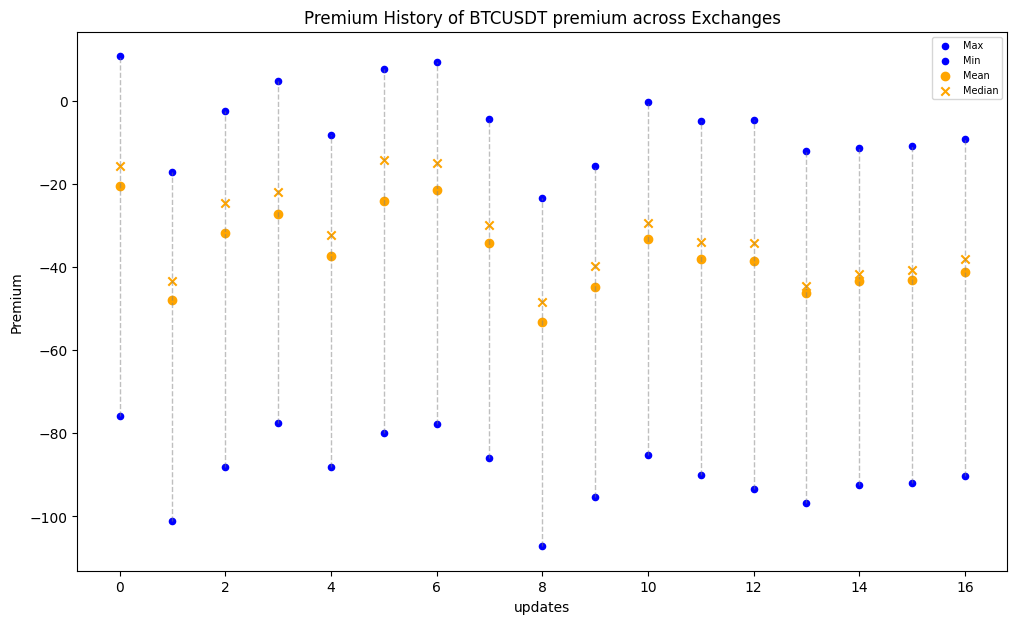

In [19]:
# Can we find a classical distribution pattern, such as skewness in the premium history of each exchange? 

padding = 0

median_list = []
color = 'orange'
plt.figure(figsize=(12, 7))
for batch in premium_history:
    plt.scatter(padding, max(batch), color='blue', s=20)
    plt.scatter(padding, min(batch), color='blue', s=20)
    plt.scatter(padding, statistics.mean(batch), color=color, marker='o')
    plt.scatter(padding, statistics.median(batch), color=color, marker='x')
    plt.vlines(padding, min(batch), max(batch), color='grey', alpha=0.5, linewidth=1, linestyle='--')
    median_list.append(statistics.median(batch))
    padding +=1

plt.legend(loc='upper right', labels=['Max', 'Min', 'Mean', 'Median'], markerscale=1, fontsize=7)
plt.xlabel("updates")
plt.ylabel("Premium")
plt.title("Premium History of BTCUSDT premium across Exchanges")
plt.show()


#### Approach 3 (Rate of Change of Medians)

We know that in cases when the market maker suspects an information asymmetry, it has to adjust its premium to be able to delta-hedge at better prices. Hence, we try to track the sensitivity of the market maker when there are consecutive same-side market hits. 

In other words, does the market maker increase the rate of change? 

To be able to test the hypothesis, we must plot a rate of change (ROC) graph and see whether we can observe an upward trend in consecutive positive ROCs (in the case of sensitivity to buy orders) and a downward trend in consecutive negative ROCs.

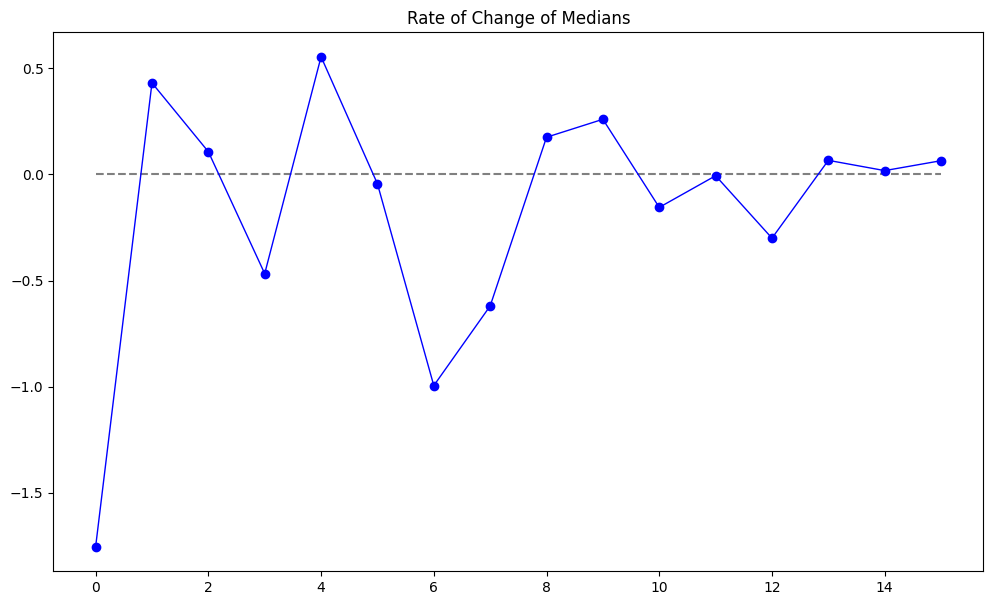

In [20]:
# Calculate the rate of change of the median values and plot it to see if there is any trend in the premium history of each exchange.

rate_of_change = []

for i in range(1, len(median_list)):
    rate_of_change.append((median_list[i] - median_list[i-1]) / abs(median_list[i-1]))
plt.figure(figsize=(12, 7))
plt.title('Rate of Change of Medians')
plt.hlines(0, 0, len(rate_of_change)-1, color='grey', linestyle='--')
plt.plot(rate_of_change, color='blue', marker='o', linewidth=1)
plt.show()

### Final Result

Therefore, in case the MM sees a possible adverse selection situation, their protection of profitability can be observed by the following approaches:
* Approach A: Charging a lower or a higher premium compared to its starting premium at $t_0$
* Approach B: The overall distribution is skewed upwards or downwards compared to the starting point at $t_0$
* Approach C: The MM becomes more sensitive to the further accumulation of positions on one side, penalizing the takers by increasing or decreasing the rate of change

All of these cases can be observed in the premium history of each exchange.